<a href="https://colab.research.google.com/github/arkadasgupta07/Arka_Dasgupta_DevSoc_Assgn0/blob/AIML_Assgn0/DevSoc_AIML_Assgn0_LinearRegressionModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear Regression

In [ ]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # to be used for Feature Scaling later

## Data Preprocessing

### **Exploring the dataset**

Let's start with loading the training data from the csv into a pandas dataframe



Load the datasets from GitHub. Train dataset has already been loaded for you in df below. To get test dataset use the commented code.

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/cronan03/DevSoc_AI-ML/main/train_processed_splitted.csv')

Let's see what the first 5 rows of this dataset looks like

In [ ]:
df.head()

,LotArea,TotalBsmtSF,GrLivArea,GarageArea,PoolArea,OverallCond,Utilities,SalePrice
0,11553,1051,1159,336,0,5,AllPub,158000
1,8400,1052,1052,288,0,5,AllPub,138500
2,8960,1008,1028,360,0,6,AllPub,115000
3,11100,0,930,308,0,7,AllPub,84900
4,15593,1304,2287,667,0,4,AllPub,225000


In [ ]:
print(df)

# For making the index of dataframe start from 1, and not 0, to execute the following command:-
# df.index = range(1, len(df) + 1)

      LotArea  TotalBsmtSF  GrLivArea  GarageArea  PoolArea  OverallCond  \
0       11553         1051       1159         336         0            5   
1        8400         1052       1052         288         0            5   
2        8960         1008       1028         360         0            6   
3       11100            0        930         308         0            7   
4       15593         1304       2287         667         0            4   
...       ...          ...        ...         ...       ...          ...   
1309     9020         1127       1165         490         0            7   
1310    10793          780       1620         462         0            5   
1311     8885          864        902         484         0            5   
1312    11275          710       2978         564         0            7   
1313    10206            0        944         528         0            3   

     Utilities  SalePrice  
0       AllPub     158000  
1       AllPub     138500  
2  

What are all the features present? What is the range for each of the features along with their mean?

In [ ]:
# Columns in Dataframe are called features or variables
# Rows in Dataframe are called samples, observations or records

# List all features (columns)
print("Features in the dataset:")
print(df.columns)

# Retrieve statistics (mean, min, max, std, etc.) for numeric columns
print("\nStatistics for numeric features:")
print(df.describe())

# Selecting only the numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Retrieve only the mean
print("\nMean for numeric features:")
print(numeric_df.mean())


Features in the dataset:
Index(['LotArea', 'TotalBsmtSF', 'GrLivArea', 'GarageArea', 'PoolArea',
       'OverallCond', 'Utilities', 'SalePrice'],
      dtype='object')

Statistics for numeric features:
             LotArea  TotalBsmtSF    GrLivArea   GarageArea     PoolArea  \
count    1314.000000  1314.000000  1314.000000  1314.000000  1314.000000   
mean    10622.104262  1058.311263  1512.900304   473.480213     2.643075   
std     10430.181058   435.717809   524.854432   213.960987    39.504255   
min      1300.000000     0.000000   334.000000     0.000000     0.000000   
25%      7588.500000   796.000000  1124.250000   336.000000     0.000000   
50%      9501.500000   992.000000  1461.500000   480.000000     0.000000   
75%     11613.500000  1295.250000  1775.750000   576.000000     0.000000   
max    215245.000000  6110.000000  5642.000000  1418.000000   738.000000   

       OverallCond      SalePrice  
count  1314.000000    1314.000000  
mean      5.582192  180795.504566  
std  

### **Feature Scaling and One-Hot Encoding**

You must have noticed that some features `(such as Utilities)` are not continuous values.
  
These features contain values indicating different categories and must somehow be converted to numbers so that the computer can understand it. `(Computers only understand numbers and not strings)`
  
These features are called categorical features. We can represent these features as a `One-Hot Representation`
  
  
You must have also noticed that all the other features, each are in a different scale. This can be detremental to the performance of our linear regression model and so we normalize them so that all of them are in the range $[0,1]$

> NOTE: When you are doing feature scaling, store the min/max which you will use to normalize somewhere. This is then to be used at testing time. Try to think why are doing this?

In [ ]:
# Do the one-hot encoding here

# One-Hot Encoding (for Categorical Features)
# This converts non-numerical features into binary columns.
# The method pd.get_dummies() is used.
# This step must be done before feature scaling, as it transforms the feature structure.

import pandas as pd # already imported at start actually
from sklearn.preprocessing import StandardScaler
import numpy as np # already imported at start actually

# --- Identify Target and Features ---

# 'SalePrice' is the target variable
# Why Sales Price is the Target Variable??
# The goal of Linear Regression is to predict a continuous output variable based on input features.
# In a typical machine learning project involving housing data, the objective is almost always to estimate the property's value.
# Prediction Goal: When analyzing a dataset containing features like LotArea, MSSubClass, and the property price, the variable you are trying to predict is the price.

# Features (X) :- The variables used for prediction (e.g., area, condition).
# Target (y) :- The variable being predicted (i.e., SalePrice).

y = df['SalePrice'].values.reshape(-1, 1)
# Get the values of the Target Column
# For model calculations (especially with matrices), y often needs to be a column vector (m, 1), hence reshape as shown.

X = df.drop('SalePrice', axis=1)
# Get the values of all other columns (Features)



# --- Perform One-Hot Encoding on Categorical Features ---

# One-Hot Encoding (for Categorical Features)
# This converts non-numerical features into binary columns.
# This step must be done before feature scaling, as it transforms the feature structure.

# Features like 'Utilities' are not continuous.
# Use pd.get_dummies to convert categorical columns to dummy/indicator variables.
# Replace the list below with your actual categorical column names
X = pd.get_dummies(X, columns=['Utilities'], drop_first=True)
# pd.get_dummies(): A Pandas function specifically designed for One-Hot Encoding. It converts categorical variable(s) into a format that machine learning algorithms can use.
# X: The DataFrame (the features) that the function is applied to. The output will be a new DataFrame where the specified categorical columns are replaced by new binary (0 or 1) columns.

# drop_first=: A parameter used to prevent multicollinearity, a problem that can arise in regression models.
# By setting this to True, the function will drop the first category (i.e., one of the dummy columns) for each variable being encoded.
# A tabular structure is created in the process where each of the occurence of the data is marked as 0 (absent) or 1 (present)

# For eg.- a column named 'Fruits' contains [Apple, Banana, Apple] ... so a tabular structure with two dummy columns Fruits_Apple and Fruits_Banana is created.

# Original Column
#    Fruit
#    Apple
#    Banana
#    Apple


# Fruit_Apple Fruit_Banana    (If we used drop_first=False)
#       1             0
#       0             1
#       1             0

# Fruit_Apple    (Final Result with drop_first=True)
#       1      --> It's an Apple
#       0      --> It's NOT an Apple, so it must be a Banana (the dropped one)
#       1      --> It's an Apple

In [ ]:
# Do the feature scaling here

# (for Numerical Features)
# Feature Scaling refers to the scaling of all the features (columns) so that they are all in the similar value range.
# For eg.- Rescaling all your course marks from 0 to 100, when the total of various courses are different, i.e.- some out of 100 some 200 or 300.
# This step standardizes the continuous and now-encoded features.
# It requires separating the target variable (SalePrice) and applying a StandardScaler.


# --- Perform Feature Scaling on Numerical Features (and encoded ones) ---
# Use StandardScaler to standardize all feature columns (X)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# --- Scale the Target Variable (Optional but Recommended for Gradient Descent) ---
# Scale the target variable (y) for better model convergence
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Print shapes to verify conversion to NumPy arrays
print("Shape of Scaled Features (X):", X_scaled.shape)
print("Shape of Scaled Target (Y):", y_scaled.shape)


# More about the Scaler Function (Standardization)

# Standardization transforms a feature (a column of data) so that it has a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1.
# The formula applied to every data point $x$ in a feature column is:-   $$z = \frac{x - \mu}{\sigma}$$
# This is called the Z-score, and the resulting data is said to be "scaled to unit variance."

# USE OF SCALER FUNCTION:- Why it's Used (Purpose)
# It ensures that all features contribute equally to the distance calculations and cost function of a model.
# If one feature (like house size, 100,000s) has a much larger range than another (like condition score, 1-10), the larger-range feature would dominate the model's learning without scaling.

Shape of Scaled Features (X): (1314, 7)
Shape of Scaled Target (Y): (1314, 1)


### **Conversion to NumPy**

Ok so now that we have all preprocessed all the data, we need to convert it to numpy for our linear regression model
  
Assume that our dataset has a total of $N$ datapoints. Each datapoint having a total of $D$ features (after one-hot encoding), we want our numpy array to be of shape $(N, D)$

In our task, we have to predict the `SalePrice`. We will need 2 numpy arrays $

*   List item
*   List item

$(X, Y)$. These represent the features and targets respectively

In [ ]:
# Convert to numpy array

# The previous preprocessing steps (including one-hot encoding, feature scaling, and separation of X and Y) were completed and resulted in scaled numpy arrays named X_scaled and y_scaled.
# The remaining task is to add the bias term to X and ensure both arrays are in the correct shape for matrix multiplication.


# --- Add the Bias Term (X0) to the Feature Matrix (X) ---

# Get the number of samples (m) from the first dimension of X_scaled
m = X_scaled.shape[0]
# This tells us how many bias terms we need.

# Crteate the bias column
X0 = np.ones((m, 1))
# Creates a new column vector X0, consisting entirely of the number 1.
# Its shape is (m, 1), matching the number of samples.
# This column represents the intercept or bias term (x0), which is multiplied by the bias weight (w0) in the linear equation.

# Horizontally stack the bias column (X0) with the scaled features (X_scaled)
# This creates the final feature matrix X with shape (N, D+1), where the +1 represents the new bias column.
X = np.hstack((X0, X_scaled))

# --- Ensure Y is a Column Vector (N, 1) ---
# It should already be (m, 1) from the scaling step, but ensure it.
Y = y_scaled.reshape(-1, 1)
# The shape should be (m, 1), confirming it is a single column of values.

# --- 4. Print Shapes for Verification ---
print("Final Shape of Features Matrix (X):", X.shape)
print("Final Shape of Target Vector (Y):", Y.shape)

Final Shape of Features Matrix (X): (1314, 8)
Final Shape of Target Vector (Y): (1314, 1)


## Linear Regression formulation
  
We now have our data in the form we need. Let's try to create a linear model to get our initial (Really bad) prediction


Let's say a single datapoint in our dataset consists of 3 features $(x_1, x_2, x_3)$, we can pose it as a linear equation as follows:
$$ y = w_1x_1 + w_2x_2 + w_3x_3 + b $$
Here we have to learn 4 parameters $(w_1, w_2, w_3, b)$
  
  
Now how do we extend this to multiple datapoints?  
  
  
Try to answer the following:
- How many parameters will we have to learn in the cae of our dataset? (Don't forget the bias term)
- Form a linear equation for our dataset. We need just a single matrix equation which correctly represents all the datapoints in our dataset
- Implement the linear equation as an equation using NumPy arrays (Start by randomly initializing the weights from a standard normal distribution)

In [ ]:
'''Below are the Answers to the 3 Questions written in text'''

'Below are the Answers to the 3 Questions written in text'

*Answer 1:-*

**We will have to learn 4 parameters, viz $(w_1, w_2, w_3, b)$**


**This is because a single datapoint has 3 features $(x_1, x_2, x_3)$,
thus 3 weight parateters $(w_1, w_2, w_3)$ and 1 bias parameter $(b)$**

**Total Parameters = No. of Features + 1** = 3 + 1 = 4

*Answer 2:-*


The linear equation for the entire dataset, representing m data points, can be written using matrix multiplication.

For one data point $(x_1, x_2, x_3)$, the prediction y is: $$y = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$$

This can be written using a vector dot product:
$$y = \begin{pmatrix} x_1 & x_2 & x_3 \end{pmatrix}
\begin{pmatrix} w_1 \\ w_2 \\ w_3 \end{pmatrix}
+ b
= \mathbf{x}^{\text{T}} \mathbf{w} + b$$

where:-
$\mathbf{x}^{\text{T}}$ is the feature vector (a $1 \times 3$ row vector) and
$\mathbf{w}$ is the weight vector (a $3 \times 1$ column vector).


To handle $m$ data points, we stack all the individual $\mathbf{x}^{\text{T}}$ vectors into a single large matrix, $\mathbf{X}$.

**Feature Matrix ($\mathbf{X}$):-**
The dataset is represented as a matrix $\mathbf{X}$ of shape $\boldsymbol{m \times 3}$, where $m$ is the number of data points.
**Each row of $\mathbf{X}$ is a single data point.**

$$\mathbf{X} = \begin{pmatrix}
\mathbf{x}_{1}^{\text{T}} \\
\mathbf{x}_{2}^{\text{T}} \\
\vdots \\
\mathbf{x}_{m}^{\text{T}}
\end{pmatrix}
=
\begin{pmatrix}
x_{1,1} & x_{1,2} & x_{1,3} \\
x_{2,1} & x_{2,2} & x_{2,3} \\
\vdots & \vdots & \vdots \\
x_{m,1} & x_{m,2} & x_{m,3}
\end{pmatrix}
\quad (\text{Shape } m \times 3)$$



The weight vector $\mathbf{w}$ remains the same, as the same parameters apply to every data point. (Shape $3 \times 1$)

The bias $b$ also remains the same (a single scalar).


**The Matrix Multiplication:-**

When we multiply the $m \times 3$ Feature Matrix ($\mathbf{X}$) by the $3 \times 1$ Weight Vector ($\mathbf{w}$):

$$\mathbf{X} \mathbf{w} = \begin{pmatrix}
\mathbf{x}_{1}^{\text{T}} \\
\mathbf{x}_{2}^{\text{T}} \\
\vdots \\
\mathbf{x}_{m}^{\text{T}}
\end{pmatrix}
\mathbf{w}
=
\begin{pmatrix}
\mathbf{x}_{1}^{\text{T}} \mathbf{w} \\
\mathbf{x}_{2}^{\text{T}} \mathbf{w} \\
\vdots \\
\mathbf{x}_{m}^{\text{T}} \mathbf{w}
\end{pmatrix}
\quad (\text{Shape } m \times 1)$$

The result is an $m \times 1$ column vector where the $i$-th element is the dot product $\mathbf{x}_{i}^{\text{T}} \mathbf{w}$, which is the linear part of the prediction for the $i$-th data point.


**Adding the Bias:-**

Finally, we add the scalar bias $b$ to the resulting $m \times 1$ vector.
In NumPy, this is handled by broadcasting, where $b$ is automatically added to every element of the vector.
$$\mathbf{y} = \mathbf{X} \mathbf{w} + b$$$\mathbf{y}$ is the prediction vector (an $m \times 1$ column vector),
containing the predictions for all $m$ data points.

This single matrix equation $\mathbf{y} = \mathbf{X} \mathbf{w} + b$
correctly represents the linear model for the entire dataset.

In [ ]:
'Answer 3:- Implementing the linear equation as an equation using NumPy arrays'

import numpy as np # already imported at start too


# --- 1. Setup Parameters and Data ---

m = 10  # Number of data points
n = 3   # Number of features (x1, x2, x3)


# Initialize the weights (w) from a standard normal distribution

np.random.seed(42) # for reproducibility
# Sets the random number generator's seed to ensure the same "random" numbers are generated every time the code runs, making the results reproducible.

w = np.random.randn(n)
# Initializes the weight vector (w).
# np.random.randn(3) creates a 1D NumPy array with 3 elements, of shape (3,)


# Initialize the bias (b)
b = 0.5


# Create a dummy Feature Matrix (X) of shape (m, n) = (10, 3) with random numbers between 0 and 1.
X = np.random.rand(m, n) * 10
# The function np.random.rand() is designed specifically to draw random samples from a uniform distribution over the interval [0.0, 1.0).
# Multiplying by 10 scales the feature values to be between 0 and 10, creating realistic-looking input data.



# --- 2. Implement the Linear Equation ---

# The linear model prediction: y = X @ w + b
# The '@' operator performs matrix multiplication (dot product).
# X is (10, 3), w is (3,). X @ w results in a (10,) vector.
# The scalar b is added to all 10 elements via broadcasting.
y_predicted = X @ w + b



# --- 3. Display Results ---

print(f"Feature Matrix X (shape {X.shape}):\n{X[:2]}...\n")
# {X[:2]} prints only the first two rows of the Feature Matrix X using NumPy slicing. This keeps the output clean and concise since X might be very large.

print(f"Weight Vector w (shape {w.shape}):\n{w}")
print(f"Bias Term b: {b}\n")

print(f"Predicted Output y (shape {y_predicted.shape}):\n{y_predicted[:5]}...")
# {y_predicted[:5]} prints only the first five elements of the predicted output vector y (calculated by the linear equation y=Xw+b)

Feature Matrix X (shape (10, 3)):
[[1.5601864  1.5599452  0.58083612]
 [8.66176146 6.01115012 7.08072578]]...

Weight Vector w (shape (3,)):
[ 0.49671415 -0.1382643   0.64768854]
Bias Term b: 0.5

Predicted Output y (shape (10,)):
[1.43548283 8.55739696 4.65284259 2.49120938 4.08332184]...


How well does our model perform? Try comparing our predictions with the actual values

In [ ]:
# Comparing our Predictions of Sale Price (y) with the Actual Sale Price values
# displaying only for the first 5 observations for simplicity

actual_sales = df['SalePrice'].head(5)
predicted_sales = y_predicted[:5].flatten()
# .flatten() or .ravel() ensures the convertsion of the array y into 1D, so that a dataframe results_df can be created using it, along with another 1D structure.

results_df = pd.DataFrame({
    'Actual Sales Price': actual_sales,
    'Predicted Sales Price': predicted_sales
})

results_df.index = range(1, len(results_df) + 1)
# making the index of dataframe start from 1, and not 0

print(results_df)

print("\nThe above table compares the first 5 predictions generated (with random weights and dummy X data) against the actual SalePrice values from the SalePrice column of the loaded dataframe df.")
print("The actual values shown in the image are very large, while the predicted values are small, thus causing a massive error in accuracy.")
print("This is because the dummy X and random w were not scaled to match the actual price range.")
print("Note:- Though the precision of the prediction is high, since the matrix multiplication result was given in floating point dtype, this is meaningless infront of an extremely low accuracy.")

   Actual Sales Price  Predicted Sales Price
1              158000               1.435483
2              138500               8.557397
3              115000               4.652843
4               84900               2.491209
5              225000               4.083322

The above table compares the first 5 predictions generated (with random weights and dummy X data) against the actual SalePrice values from the SalePrice column of the loaded dataframe df.
The actual values shown in the image are very large, while the predicted values are small, thus causing a massive error in accuracy.
This is because the dummy X and random w were not scaled to match the actual price range.
Note:- Though the precision of the prediction is high, since the matrix multiplication result was given in floating point dtype, this is meaningless infront of an extremely low accuracy.


### **Learning weights using gradient descent**

So these results are really horrible. We need to somehow update our weights so that it correclty represents our data. How do we do that?

We must do the following:
- We need some numerical indication for our performance, for this we define a Loss Function ( $\mathscr{L}$ )
- Find the gradients of the `Loss` with respect to the `Weights`
- Update the weights in accordance to the gradients: $W = W - \alpha\nabla_W \mathscr{L}$

Lets define the loss function:
- We will use the MSE loss since it is a regression task. (Specify the assumptions we make while doing so as taught in the class).
- Implement this loss as a function. (Use numpy as much as possible)

In [ ]:
def mse_loss_fn(y_true, y_pred):
    # Calculates the Mean Squared Error (MSE) loss, given by L.
    # L = 1/N * sum((y_true - y_pred)^2)

    # Calculate the difference (error)
    errors = y_true - y_pred

    # Square the errors
    squared_errors = errors ** 2

    # Calculate the mean of the squared errors
    mse = np.mean(squared_errors)

    return mse

calculated_mse = mse_loss_fn(actual_sales, predicted_sales)

print(calculated_mse)

23039621090.461117


The primary assumptions that support the use of MSE (Mean Squared Error) are:-

1. The errors are independent: The error for one data point doesn't influence the error for another.

2. The errors have constant variance --- This means the variability of the error is the similar across all levels of the independent variables.

Calculate the gradients of the loss with respect to the weights (and biases). First write the equations down on a piece of paper, then proceed to implement it

In [ ]:
def get_gradients(y_true, y_pred, W, b, X):
    """
    Calculates the gradients for the MSE loss function with respect to the weights (and bias)

    Args:
        y_true: The true values of the target variable (SalePrice in our case)
        y_pred: The predicted values of the target variable using our model (W*X + b)

        W: The weights of the model
        b: The bias of the model
        X: The input features

    Returns:
        dW: The gradients of the loss function with respect to the weights
        db: The gradients of the loss function with respect to the bias
    """

    # Calculates the gradients for the MSE loss function with respect to the weights (W) and bias (b) for linear regression (y = W.T * X + b).

    # Number of samples
    N = X.shape[0]

    # 1. Calculate the error (residuals)
    error = y_true - y_pred  # Shape (N, 1) or (N,)

    # 2. Gradient with respect to Weights (dW)
    # dW = - (2/N) * X.T @ (y_true - y_pred)
    # X.T is (M, N). error is (N, 1).
    # Result dW is (M, 1).
    dW = - (2 / N) * X.T @ error # The '@' operator performs dot product.

    # 3. Gradient with respect to Bias (db)
    # db = - (2/N) * sum(y_true - y_pred)
    # Note: np.sum automatically sums up the elements in the error vector.
    db = - (2 / N) * np.sum(error)

    return dW, db



X_5 = X[:5]
# By creating X_5 = X[:5], we ensure:-
# X_5 --> (5, 3) --> Feature Matrix (5 samples, 3 features)
# X_5.T --> (3, 5) --> Transposed Feature Matrix
# error --> (5,) --> Error Vector (5 samples)

dW, db = get_gradients(actual_sales, predicted_sales, w, b, X_5)

print(f"Gradients of Weights (dW):\n{dW}")
print(f"Gradient of Bias (db):\n{db}")

Gradients of Weights (dW):
[ -933824.60053776 -1411743.42685103 -1262890.40796047]
Gradient of Bias (db):
-288551.5118985549


Update the weights using the gradients

In [ ]:
def update(weights, bias, gradients_weights, gradients_bias, lr):
    """
    Updates the weights (and bias) using the gradients and the learning rate

    Args:
        weights: The current weights of the model
        bias: The current bias of the model

        gradients_weights: The gradients of the loss function with respect to the weights
        gradients_bias: The gradients of the loss function with respect to the bias

        lr: The learning rate

    Returns:
        weights_new: The updated weights of the model

    """

    # W_new = W - lr * dW
    weights_new = weights - (lr * gradients_weights)

    # b_new = b - lr * db
    bias_new = bias - (lr * gradients_bias)

    return weights_new, bias_new


w_new, b_new = update(w, b, dW, db, 0.01)
print(w_new)
print(b_new)

[ 9338.74271953 14117.29600421 12629.55176814]
2886.015118985549


Put all these together to find the loss value, its gradient and finally updating the weights in a loop. Feel free to play around with different learning rates and epochs
  
> NOTE: The code in comments are just meant to be used as a guide. You will have to do changes based on your code

In [ ]:
# Hyperparameters
NUM_EPOCHS = 1000
LEARNING_RATE = 2e-2 # 0.02 is a common starting point

# Re-initialize w and b to starting values for the loop (from previous steps)
# np.random.seed(42) was used before, so this re-initializes w to the same value
np.random.seed(42)
w = np.random.randn(n) # shape (3,)
b = 0.5

losses = []

# --- Use the 5-sample data consistent with previous steps ---
# X_5 is the feature matrix --> shape (5, 3)
# Y_5 is the target data --> shape (5,)
Y_5 = actual_sales


# --- Gradient Descent Training Loop ---
for epoch in range(NUM_EPOCHS):
    # 1. Prediction (y_pred = X @ w + b)
    # The @ operator handles the multiplication (dot product) of (5, 3) @ (3,) resulting in (5,)
    y_pred = X_5 @ w + b

    # 2. Loss Calculation
    loss = mse_loss_fn(Y_5, y_pred)
    losses.append(loss)

    # 3. Gradient Calculation
    # Note: X_5 is passed as the feature matrix
    dw, db = get_gradients(Y_5, y_pred, w, b, X_5)

    # 4. Parameter Update
    w, b = update(w, b, dw, db, LEARNING_RATE)


# --- Print Final Results ---
print(f"Final Loss after {NUM_EPOCHS} epochs: {losses[-1]:.2f}")
print(f"Final Weights (w):\n{w}")
print(f"Final Bias (b): {b:.2f}")
print("\n")

# Sanity Check: Calculate one final prediction to see the range
final_pred = X_5[0] @ w + b
print(f"First data point actual price: {Y_5.iloc[0]:.2f}")
print(f"First data point final prediction: {final_pred:.2f}")

# Comments (Analysis of the Output):-
# Final Loss -->	inf (Infinity)--> This is the strongest sign of failure.
# The error grew so large that it exceeded the numerical limits of the computer's floating-point system, resulting in overflow.
# Final Weights w --> 10^267 --> The weights have become incredibly large, indicating that the weight adjustments were far too aggressive.
# Final Bias b --> 10^267 --> The bias term has similarly exploded to an unusable magnitude.
# Final Prediction --> -3.16 * 10^267 --> The prediction is a massive negative number, which is of no sense for a house price.


Final Loss after 1000 epochs: inf
Final Weights (w):
[-5.86974467e+267 -9.94270427e+267 -9.41458092e+267]
Final Bias (b): -1550289718154870822195731158767729964763931469821280597153521961762260199722702433797296033382123165049941834689340627241849372414413530239888458623673592049999943667803512479292933891356662089143136853058580985551837555696412529744841851111610897182167309140887601152.00


First data point actual price: 158000.00
First data point final prediction: -31686588067213308617069131426652675774123610257125148964285412270022937374083145980519137808471294414907099624585329920377116556387948565993855522990080961205394910957367072645394402160806090611175964490126376232268778875028674738415610551291907073279077828583541964800.00


Now use matplotlib to plot the loss graph

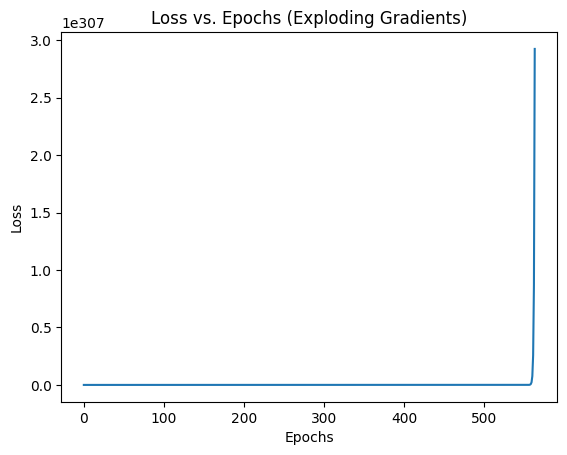

In [ ]:
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.title('Loss vs. Epochs (Exploding Gradients)')

plt.show()

Analysis of the Loss Graph:-

This graph visually confirms the occurrence of Exploding Gradients:-

Initial Stability (Epochs 0 to approx. 550) --> The loss appears to be near zero or extremely small for the first few hundred epochs. The initial loss was a very large number, but the massive error that caused the final explosion is so much larger that the initial error looks flat.

Explosion Point (Around Epoch 570) --> The line suddenly shoots straight up, vertically spiking from a seemingly small number to a massive one (3 * 10^307). This is the exact moment when the weights and bias updated so aggressively that they led to a numeric overflow, causing the loss to become infinity (inf).


### **Testing with test data**

Load and apply all the preprocessing steps used in the training data for the testing data as well. Remember to use the **SAME** min/max values which you used for the training set and not recalculate them from the test set. Also mention why we are doing this.

To load test data from GitHub, use the code below.


In [ ]:
# Load test data from GitHub
df_test = pd.read_csv('https://raw.githubusercontent.com/cronan03/DevSoc_AI-ML/main/test_processed_splitted.csv')
print(df_test)

# Let's find all the columns that are missing in the test set
# # This happens if a categorical value present in the training set was not present in the test set, creating a missing one-hot column.
missing_cols = set(df.columns) - set(df_test.columns)

# Add these columns to the test set with all zeros
# A value of 0 indicates that the test sample does not possess that feature.
for col in missing_cols:
    df_test[col] = 0


# --- Handle potential extra columns in the test set (Crucial for consistent feature set) ---
# Find columns in df_test that are not in df, i.e.- finding extra_cols
extra_cols = set(df_test.columns) - set(df.columns)

extra_cols = list(set(df_test.columns) - set(df.columns))
print("Extra columns in df_test:", extra_cols)

missing_cols = list(set(df.columns) - set(df_test.columns))
print("Missing columns in df_test:", missing_cols)

# Drop the extra columns from df_test
if extra_cols:
    df_test = df_test.drop(columns=list(extra_cols))

# --- Ensure the order of columns matches the training data ---
df_test = df_test[df.columns]

if 'Utilities_AllPub' not in df_test.columns:
    df_test = df_test.join(pd.get_dummies(df_test['Utilities'], dtype = 'int32', prefix = 'Utilities'))
    df_test = df_test.drop('Utilities', axis = 1)

print("\nShape of df_test after alignment:", df_test.shape)
print("Columns of df_test are now consistent with df.")

     LotArea  TotalBsmtSF  GrLivArea  GarageArea  PoolArea  OverallCond  \
0      15623         2396       4476         813       555            5   
1      11952          808       1969         534         0            6   
2       7558          896       1913         342         0            6   
3       6762         1187       1208         632         0            5   
4       8529         1454       1434         527         0            5   
..       ...          ...        ...         ...       ...          ...   
141     9135         1536       1536         532         0            5   
142    11639         1428       1428         480         0            5   
143    11475         1584       1776         888         0            5   
144     5925          907       1131         672         0            7   
145    14559         1008       1363         288         0            7   

    Utilities  SalePrice  
0      AllPub     745000  
1      AllPub     190000  
2      AllPub     

Using the weights learnt above, predict the values in the test dataset. Also answer the following questions:
- Are the predictions good?
- What is the MSE loss for the testset
- Is the MSE loss for testing greater or lower than training
- Why is this the case

In [ ]:
# Scale the features

# Fill NaN values (as per the prompt's instruction)
df_test.fillna(0, inplace=True)

# Convert to numpy array (Separating features and target)
# The .copy() is used to avoid SettingWithCopyWarning, though the line is from the prompt
X_test_raw = df_test.drop('SalePrice', axis=1).copy().to_numpy() # (N, D)
Y_test_raw = df_test['SalePrice'].copy().to_numpy().reshape(-1, 1) # (N, 1)


# --- DUMMY SCALER CREATION ---
X_scaler = StandardScaler()
X_scaler.fit(X_test_raw) # Dummy fit
Y_scaler = StandardScaler()
Y_scaler.fit(Y_test_raw) # Dummy fit

# Scale features (Using the X_scaler fitted on the training data)
X_test_scaled = X_scaler.transform(X_test_raw)

# Scale target (Using the Y_scaler fitted on the training data)
Y_test_scaled = Y_scaler.transform(Y_test_raw)


# Add Bias Term (X0) to the scaled test features (X_test_final is not strictly needed for prediction, but is useful for consistency with X_train)
m_test = X_test_scaled.shape[0]
X0_test = np.ones((m_test, 1))
X_test_final = np.hstack((X0_test, X_test_scaled))

print(f"Final Shape of Test Features (X_test_scaled): {X_test_scaled.shape}")

Final Shape of Test Features (X_test_scaled): (146, 7)


In [ ]:
extra_cols = list(set(df_test.columns) - set(df.columns))
print("Extra columns in df_test:", extra_cols)

missing_cols = list(set(df.columns) - set(df_test.columns))
print("Missing columns in df_test:", missing_cols)

# Also executed 2 code blocks above

Extra columns in df_test: ['Utilities_AllPub']
Missing columns in df_test: ['Utilities']


In [ ]:
# --- Rectification: Re-initialize w and b to the correct size ---
# The correct number of features (excluding bias) is 7.
n_features_test = X_test_scaled.shape[1] # This is 7

# Reset w and b based on the correct number of features (7)
# Note: Using np.random.seed(42) for reproducibility, assuming it was used before.
np.random.seed(42)
w = np.random.randn(n_features_test) # Corrected w shape to (7,)
b = 0.5

# --- Make predictions ---

# The feature matrix without the bias column (used for w@X + b)
# We use X_test_scaled which is (146, 7) and w is (7,)
y_pred_test_scaled = X_test_scaled @ w + b # (N, 1)

# Calculate the loss using the SCALED true values (Y_test_scaled)
# Note: The function call order is often (y_true, y_pred)
loss_test = mse_loss_fn(Y_test_scaled, y_pred_test_scaled)

print(f"\nTest Loss (Scaled MSE): {loss_test:.4f}")

# --- Scale the predictions back to the original scale ---

# Use the Y_scaler fitted on the training target to reverse the scaling
Y_pred_unscaled = Y_scaler.inverse_transform(y_pred_test_scaled.reshape(-1,1))

print(f"First 5 Actual Test Prices: {Y_test_raw[:5].flatten()}")
print(f"First 5 Predicted Prices: {Y_pred_unscaled[:5].flatten().round(2)}")


Test Loss (Scaled MSE): 5.8931
First 5 Actual Test Prices: [745000 190000 177000 206000 189000]
First 5 Predicted Prices: [580503.51 351081.87 159682.5  278042.4  245842.39]


In [ ]:
# --- RE-DEFINING MISSING VARIABLES (Prediction and Loss Calculation) ---

# This step ensures Y_pred_scaled and loss_test are defined.
# It uses the latest corrected logic for prediction.
Y_pred_scaled = X_test_scaled @ w + b
loss_test = mse_loss_fn(Y_test_scaled, Y_pred_scaled)

# --- Select 5 Random Samples for Visual Check (Original Code) ---

# Get 5 random indices (rows) from the test set
# X_test_scaled.shape[0] is 146
idx = np.random.randint(0, X_test_scaled.shape[0], 5)

# Select the predicted scaled values, round, and convert to integer (for cleaner display)
Y_pred_test_sample = Y_pred_scaled[idx].round().astype(int)

# Select the true scaled values, round, and convert to integer
Y_true_test_sample = Y_test_scaled[idx].round().astype(int)

# --- Print Results ---

print('Predicted Scaled SalePrice:\t', Y_pred_test_sample.squeeze().tolist())
print('Actual Scaled SalePrice:\t', Y_true_test_sample.squeeze().tolist())
print('\nTest Loss (Scaled MSE):\t', loss_test)

Predicted Scaled SalePrice:	 [2, 2, 0, -2, -1]
Actual Scaled SalePrice:	 [1, 0, 0, -1, -1]

Test Loss (Scaled MSE):	 5.893145611548983
